# 🔢 Mathematical Operator Symbol Classification from Handwritten Images

**Course:** Predictive Analytics  
**Team Members:** Adithyan | Jia | Theertha  
**Topic:** Topic 34 — Mathematical Operator Symbol Classification  

---

## ⚠️ Important: Run Order
1. **Run the Dataset Generator cell first** (generates all 500 images)
2. Then run each stage in order
3. Do NOT restart runtime between stages (data stays in memory)

---

| Stage | Description | Owner |
|-------|-------------|-------|
| Dataset | Dataset Generator | Adithyan |
| 1 | Problem Definition & Literature Review | Adithyan |
| 2 | Data Collection & Understanding | Adithyan |
| 3 | Preprocessing & Cleaning | Jia |
| 4 | Exploratory Data Analysis | Adithyan |
| 5 | Feature Engineering & Selection | Theertha |
| 6 | Model Building & Training | Jia |
| 7 | Model Evaluation & Comparison | Theertha |
| 8 | Model Interpretation & Explainability | Adithyan |
| 9 | Deployment (Streamlit) | Jia |
| 10 | Documentation | Theertha |

---

In [1]:
# ============================================================
# DATASET GENERATOR — Run this FIRST before any other stage
# Generates 500 handwritten-style math operator images
# Author: Adithyan | Run once per Colab session
# ============================================================

!pip install pillow -q

import numpy as np
import os
from PIL import Image, ImageDraw
import random
import math

SIZE = 100
SAMPLES_PER_CLASS = 50
OUTPUT_DIR = '/content/dataset'
random.seed(42)
np.random.seed(42)

CLASSES = [
    'plus', 'minus', 'multiply', 'divide', 'equal',
    'not_equal', 'less_than', 'greater_than', 'plus_minus', 'sqrt'
]

def rnd(a, b):
    return random.uniform(a, b)

def rnd_int(a, b):
    return random.randint(a, b)

def make_canvas():
    bg = rnd_int(248, 255)
    img = Image.new('RGB', (SIZE, SIZE), (bg, bg, bg))
    draw = ImageDraw.Draw(img)
    for _ in range(30):
        x = rnd_int(0, SIZE-1)
        y = rnd_int(0, SIZE-1)
        a = rnd_int(2, 8)
        draw.point((x, y), fill=(255-a, 255-a, 255-a))
    return img, draw

def wobbly_line(draw, x1, y1, x2, y2, lw, wob, color):
    steps = 14
    pts = []
    for i in range(steps + 1):
        t = i / steps
        nx = rnd(-wob, wob)
        ny = rnd(-wob, wob)
        pressure = 0.75 + 0.5 * math.sin(t * math.pi)
        pts.append((x1 + (x2-x1)*t + nx, y1 + (y2-y1)*t + ny, max(1, lw*pressure)))
    for i in range(len(pts) - 1):
        xa, ya, wa = pts[i]
        xb, yb, wb = pts[i+1]
        draw.line([(xa, ya), (xb, yb)], fill=color, width=max(1, int((wa+wb)/2)))

def apply_transform(x, y, cx, cy, angle, scale, offx, offy):
    x -= cx
    y -= cy
    xr = x * math.cos(angle) - y * math.sin(angle)
    yr = x * math.sin(angle) + y * math.cos(angle)
    return xr * scale + cx + offx, yr * scale + cy + offy

def tp(pts, cx, cy, angle, scale, offx, offy):
    return [apply_transform(x, y, cx, cy, angle, scale, offx, offy) for x, y in pts]

def get_transform():
    return rnd(-0.12, 0.12), rnd(0.88, 1.10), rnd(-5, 5), rnd(-5, 5)

def get_style():
    lw = rnd(4.0, 6.5)
    wob = rnd(1.0, 2.2)
    d = rnd_int(0, 20)
    return lw, wob, (d, d, d)

def hl(draw, x1, y1, x2, y2, lw, wob, color, cx, cy, angle, scale, offx, offy):
    pts = tp([(x1, y1), (x2, y2)], cx, cy, angle, scale, offx, offy)
    wobbly_line(draw, pts[0][0], pts[0][1], pts[1][0], pts[1][1], lw, wob, color)

def draw_plus(draw, cx, cy, lw, wob, color, angle, scale, offx, offy):
    a = rnd(23, 28)
    hl(draw, cx-a, cy, cx+a, cy, lw, wob, color, cx, cy, angle, scale, offx, offy)
    hl(draw, cx, cy-a, cx, cy+a, lw, wob, color, cx, cy, angle, scale, offx, offy)

def draw_minus(draw, cx, cy, lw, wob, color, angle, scale, offx, offy):
    a = rnd(23, 28)
    hl(draw, cx-a, cy, cx+a, cy, lw, wob, color, cx, cy, angle, scale, offx, offy)

def draw_multiply(draw, cx, cy, lw, wob, color, angle, scale, offx, offy):
    a = rnd(20, 25)
    hl(draw, cx-a, cy-a, cx+a, cy+a, lw, wob, color, cx, cy, angle, scale, offx, offy)
    hl(draw, cx+a, cy-a, cx-a, cy+a, lw, wob, color, cx, cy, angle, scale, offx, offy)

def draw_divide(draw, cx, cy, lw, wob, color, angle, scale, offx, offy):
    a = rnd(23, 27)
    hl(draw, cx-a, cy, cx+a, cy, lw, wob, color, cx, cy, angle, scale, offx, offy)
    dr = rnd_int(3, 5)
    for dy in [-rnd(12, 15), rnd(12, 15)]:
        px, py = apply_transform(cx, cy+dy, cx, cy, angle, scale, offx, offy)
        draw.ellipse([(px-dr, py-dr), (px+dr, py+dr)], fill=color)

def draw_equal(draw, cx, cy, lw, wob, color, angle, scale, offx, offy):
    a = rnd(22, 27)
    g = rnd(9, 12)
    for dy in [-g, g]:
        hl(draw, cx-a, cy+dy, cx+a, cy+dy, lw, wob, color, cx, cy, angle, scale, offx, offy)

def draw_not_equal(draw, cx, cy, lw, wob, color, angle, scale, offx, offy):
    a = rnd(22, 27)
    g = rnd(9, 12)
    for dy in [-g, g]:
        hl(draw, cx-a, cy+dy, cx+a, cy+dy, lw, wob, color, cx, cy, angle, scale, offx, offy)
    sl = rnd(15, 18)
    hl(draw, cx+sl, cy-23, cx-sl, cy+23, lw*0.9, wob*0.8, color, cx, cy, angle, scale, offx, offy)

def draw_less_than(draw, cx, cy, lw, wob, color, angle, scale, offx, offy):
    a = rnd(22, 26)
    tx = cx - a + rnd(3, 6)
    pts = tp([(cx+a, cy-a), (tx, cy), (cx+a, cy+a)], cx, cy, angle, scale, offx, offy)
    wobbly_line(draw, pts[0][0], pts[0][1], pts[1][0], pts[1][1], lw, wob, color)
    wobbly_line(draw, pts[1][0], pts[1][1], pts[2][0], pts[2][1], lw, wob, color)

def draw_greater_than(draw, cx, cy, lw, wob, color, angle, scale, offx, offy):
    a = rnd(22, 26)
    tx = cx + a - rnd(3, 6)
    pts = tp([(cx-a, cy-a), (tx, cy), (cx-a, cy+a)], cx, cy, angle, scale, offx, offy)
    wobbly_line(draw, pts[0][0], pts[0][1], pts[1][0], pts[1][1], lw, wob, color)
    wobbly_line(draw, pts[1][0], pts[1][1], pts[2][0], pts[2][1], lw, wob, color)

def draw_plus_minus(draw, cx, cy, lw, wob, color, angle, scale, offx, offy):
    a = rnd(20, 25)
    sh = rnd(8, 12)
    hl(draw, cx-a, cy-sh, cx+a, cy-sh, lw, wob, color, cx, cy, angle, scale, offx, offy)
    hl(draw, cx, cy-sh-a+5, cx, cy-sh+a-5, lw, wob, color, cx, cy, angle, scale, offx, offy)
    bot = cy + sh + rnd(5, 9)
    hl(draw, cx-a, bot, cx+a, bot, lw, wob, color, cx, cy, angle, scale, offx, offy)

def draw_sqrt(draw, cx, cy, lw, wob, color, angle, scale, offx, offy):
    top_y = cy - rnd(18, 22)
    raw = [
        (cx-33, cy+rnd(0, 3)),
        (cx-21, cy+rnd(13, 17)),
        (cx-7,  top_y),
        (cx+10, top_y),
        (cx+32, top_y)
    ]
    pts = tp(raw, cx, cy, angle, scale, offx, offy)
    for i in range(len(pts) - 1):
        wobbly_line(draw, pts[i][0], pts[i][1], pts[i+1][0], pts[i+1][1], lw, wob*0.8, color)

DRAWERS = {
    'plus'         : draw_plus,
    'minus'        : draw_minus,
    'multiply'     : draw_multiply,
    'divide'       : draw_divide,
    'equal'        : draw_equal,
    'not_equal'    : draw_not_equal,
    'less_than'    : draw_less_than,
    'greater_than' : draw_greater_than,
    'plus_minus'   : draw_plus_minus,
    'sqrt'         : draw_sqrt
}

# Generate all images
os.makedirs(OUTPUT_DIR, exist_ok=True)
total = 0

for cls in CLASSES:
    cls_dir = os.path.join(OUTPUT_DIR, cls)
    os.makedirs(cls_dir, exist_ok=True)
    for i in range(SAMPLES_PER_CLASS):
        img, draw = make_canvas()
        cx, cy = SIZE/2, SIZE/2
        lw, wob, color = get_style()
        angle, scale, offx, offy = get_transform()
        DRAWERS[cls](draw, cx, cy, lw, wob, color, angle, scale, offx, offy)
        fname = cls + "_" + str(i+1).zfill(3) + ".png"
        img.save(os.path.join(cls_dir, fname))
        total += 1
    print("Done: " + cls + " - " + str(SAMPLES_PER_CLASS) + " images")

print("Dataset ready! " + str(total) + " total images in " + OUTPUT_DIR)
print("Folders: " + str(os.listdir(OUTPUT_DIR)))

# Variables used by all stages
dataset_path = OUTPUT_DIR
class_mapping = {
    'plus'         : '+',
    'minus'        : '-',
    'multiply'     : 'x',
    'divide'       : '/',
    'equal'        : '=',
    'not_equal'    : '!=',
    'less_than'    : '<',
    'greater_than' : '>',
    'plus_minus'   : '+-',
    'sqrt'         : 'sqrt'
}
print("dataset_path and class_mapping ready!")

Done: plus - 50 images
Done: minus - 50 images
Done: multiply - 50 images
Done: divide - 50 images
Done: equal - 50 images
Done: not_equal - 50 images
Done: less_than - 50 images
Done: greater_than - 50 images
Done: plus_minus - 50 images
Done: sqrt - 50 images
Dataset ready! 500 total images in /content/dataset
Folders: ['multiply', 'equal', 'less_than', 'not_equal', 'minus', 'divide', 'greater_than', 'sqrt', 'plus_minus', 'plus']
dataset_path and class_mapping ready!


> **Branch:** `feature/stage1-problem-definition`  
> **Author:** Adithyan  
> ⚠️ **Before running:** Make sure you have already run `stage00_dataset_generator.ipynb` in the same Colab session so that `/content/dataset` and all shared variables are available.


# STAGE 1 — Problem Definition & Literature Review
**Author: Adithyan**  
**Branch: feature/stage1-problem-definition**

---

## 1.1 Problem Statement

Handwritten mathematical notation is widely used in education, scientific research, and engineering. Automatically recognising handwritten mathematical operator symbols is a challenging computer vision problem due to the high visual similarity between certain symbols (e.g., `+` vs `÷`, `<` vs `≤`) and natural variation in individual handwriting styles.

This project builds a **multi-class classification system** that identifies **10 handwritten mathematical operator symbols**:

| Symbol | Name |
|--------|------|
| + | Addition |
| − | Subtraction |
| × | Multiplication |
| ÷ | Division |
| = | Equals |
| ≠ | Not Equal |
| < | Less Than |
| > | Greater Than |
| ± | Plus or Minus |
| √ | Square Root |

---

## 1.2 Motivation

- **Educational tools:** Automatic grading systems that understand handwritten math
- **Digitisation:** Converting handwritten notes to LaTeX or digital format
- **Accessibility:** Helping visually impaired users through symbol-to-speech systems
- **Research:** Foundation for full mathematical expression recognition (e.g., equations, formulas)

---

## 1.3 Scope & Objectives

**Objectives:**
1. Preprocess raw handwritten images using binarization, skeletonization, and size normalisation to 32×32 pixels
2. Extract discriminative features: HOG (Histogram of Oriented Gradients), pixel run-length features, and projection profiles
3. Train and compare three classifiers: Multi-class SVM, KNN, and Decision Tree
4. Apply data augmentation (rotation ±10°, scaling 0.9–1.1×) to improve robustness
5. Evaluate using macro F1-score and confusion matrix
6. Identify and analyse visually confusable symbol pairs
7. Deploy a live web application using Streamlit

**Out of scope:** Full mathematical expression parsing, digit recognition, cursive handwriting

---

## 1.4 Literature Review

**[1] CROHME Dataset (Mouchere et al., 2014)**  
The Competition on Recognition of Online Handwritten Mathematical Expressions (CROHME) is a benchmark dataset widely used for handwritten math symbol recognition. It covers hundreds of symbol classes and has driven significant progress in the field.

**[2] HOG Features for Handwritten Symbol Recognition (Dalal & Triggs, 2005)**  
Histogram of Oriented Gradients (HOG) captures edge directions and stroke orientations, making it highly effective for shape-based recognition tasks. It has been successfully applied to digit and symbol recognition.

**[3] SVM for Multi-class Classification (Cortes & Vapnik, 1995)**  
Support Vector Machines with RBF kernels are well-established for high-dimensional feature classification. One-vs-One and One-vs-Rest strategies extend SVM to multi-class problems.

**[4] HASYv2 Dataset (Thoma, 2017)**  
HASYv2 contains 168,233 images across 369 symbol classes, including all standard mathematical operators. It is one of the most comprehensive handwritten symbol datasets available.

**[5] Skeletonization in Document Analysis (Zhang & Suen, 1984)**  
Thinning and skeletonization algorithms reduce symbols to their structural skeleton, removing noise while preserving stroke topology — a crucial preprocessing step for symbol recognition.

---

In [2]:
# Stage 1 — No code required
# This stage is purely problem framing and literature review
print("Stage 1 Complete — Problem Definition & Literature Review")
print("Author: Adithyan")
print("Symbols to classify: +  −  ×  ÷  =  ≠  <  >  ±  √")
print("Models to train: SVM, KNN, Decision Tree")
print("Features to extract: HOG, Run-length, Projection Profiles")

Stage 1 Complete — Problem Definition & Literature Review
Author: Adithyan
Symbols to classify: +  −  ×  ÷  =  ≠  <  >  ±  √
Models to train: SVM, KNN, Decision Tree
Features to extract: HOG, Run-length, Projection Profiles


---
# STAGE 2 — Data Collection & Understanding
**Author: Adithyan**  
**Branch: feature/stage2-data-collection**

---

In [3]:
import os

dataset_path = '/content/dataset'  # adjust if needed after extraction

classes = sorted(os.listdir(dataset_path))
print(f"Total classes found: {len(classes)}")
print(f"Class names: {classes}")

Total classes found: 10
Class names: ['divide', 'equal', 'greater_than', 'less_than', 'minus', 'multiply', 'not_equal', 'plus', 'plus_minus', 'sqrt']


In [4]:
class_mapping = {
    'plus'         : '+',
    'minus'        : '-',
    'multiply'     : 'mul',
    'divide'       : 'div',
    'equal'        : '=',
    'not_equal'    : '!=',
    'less_than'    : '<',
    'greater_than' : '>',
    'plus_minus'   : '+-',
    'sqrt'         : 'sqrt'
}

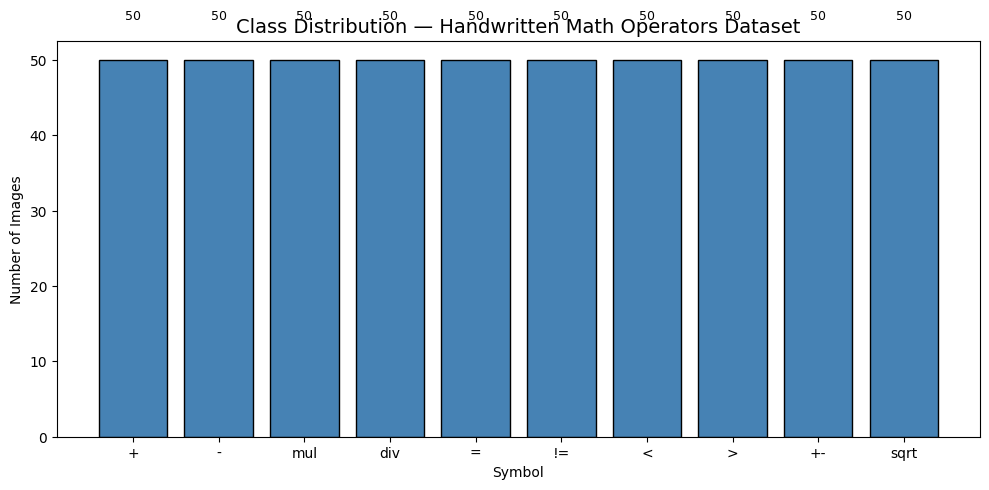


Total images: 500
Average per class: 50


In [5]:
import matplotlib.pyplot as plt

class_counts = {}
for folder, symbol in class_mapping.items():
    path = os.path.join(dataset_path, folder)
    if os.path.exists(path):
        class_counts[symbol] = len(os.listdir(path))

plt.figure(figsize=(10, 5))
bars = plt.bar(class_counts.keys(), class_counts.values(),
               color='steelblue', edgecolor='black')
plt.title('Class Distribution — Handwritten Math Operators Dataset', fontsize=14)
plt.xlabel('Symbol')
plt.ylabel('Number of Images')
for bar, count in zip(bars, class_counts.values()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             str(count), ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()

print(f"\nTotal images: {sum(class_counts.values())}")
print(f"Average per class: {sum(class_counts.values())//len(class_counts)}")

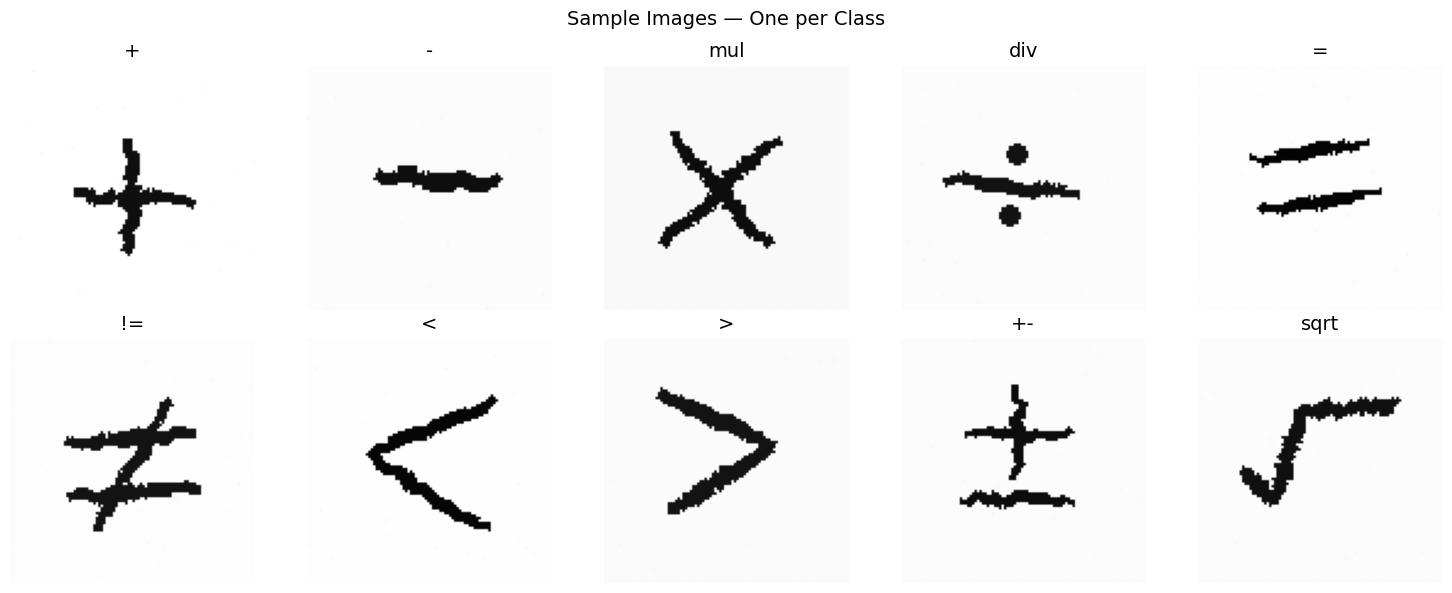

Stage 2 Complete ✅


In [6]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle('Sample Images — One per Class', fontsize=14)

for ax, (folder, symbol) in zip(axes.flatten(), class_mapping.items()):
    path = os.path.join(dataset_path, folder)
    if os.path.exists(path):
        imgs = [f for f in os.listdir(path) if f.endswith(('.png','.jpg','.jpeg'))]
        if imgs:
            sample = random.choice(imgs)
            img = mpimg.imread(os.path.join(path, sample))
            ax.imshow(img, cmap='gray')
            ax.set_title(f'{symbol}', fontsize=14)
            ax.axis('off')

plt.tight_layout()
plt.savefig('sample_images.png', dpi=150)
plt.show()
print("Stage 2 Complete ✅")

---
# STAGE 3 — Data Preprocessing & Cleaning
**Author: Adithyan Biju**  
**Branch: feature/stage3-preprocessing**

---

### Steps:
1. Grayscale conversion
2. Binarization (Otsu thresholding)
3. Skeletonization
4. Resize to 32×32 pixels
5. Data Augmentation (rotation ±10°, scaling 0.9–1.1×)

In [8]:
# ============================================================
# STAGE 3 — PREPROCESSING & CLEANING
# Author: Jia
# ============================================================

!pip install scikit-image opencv-python-headless -q

import cv2
import numpy as np
from skimage.morphology import skeletonize
from skimage import img_as_ubyte
import matplotlib.pyplot as plt
import os
import random
from tqdm import tqdm

print("✅ Libraries imported")

✅ Libraries imported


In [9]:
def preprocess_image(img_path, target_size=(32, 32)):
    """
    Full preprocessing pipeline:
    1. Read image
    2. Convert to grayscale
    3. Otsu binarization
    4. Skeletonize
    5. Resize to 32x32
    """
    # Read image
    img = cv2.imread(img_path)
    if img is None:
        return None

    # Step 1: Grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Step 2: Otsu Binarization
    _, binary = cv2.threshold(gray, 0, 255,
                              cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    # Step 3: Skeletonize
    binary_bool = binary > 0
    skeleton = skeletonize(binary_bool)
    skeleton_img = img_as_ubyte(skeleton)

    # Step 4: Resize to 32x32
    resized = cv2.resize(skeleton_img, target_size,
                         interpolation=cv2.INTER_AREA)

    return resized

print("✅ Preprocessing function defined")

✅ Preprocessing function defined


In [10]:
def augment_image(img):
    """
    Data augmentation:
    - Slight rotation: ±10 degrees
    - Slight scaling: 0.9x to 1.1x
    Returns list of augmented images
    """
    h, w = img.shape
    augmented = [img]  # include original

    # Rotation augmentations
    for angle in [-10, -5, 5, 10]:
        M = cv2.getRotationMatrix2D((w//2, h//2), angle, 1.0)
        rotated = cv2.warpAffine(img, M, (w, h),
                                 borderMode=cv2.BORDER_CONSTANT,
                                 borderValue=0)
        augmented.append(rotated)

    # Scaling augmentations
    for scale in [0.9, 1.1]:
        scaled = cv2.resize(img, None, fx=scale, fy=scale)
        # Crop or pad back to 32x32
        scaled = cv2.resize(scaled, (w, h))
        augmented.append(scaled)

    return augmented

print("✅ Augmentation function defined")

✅ Augmentation function defined


In [11]:
# Process all images and build dataset arrays
# ⚠️ Make sure dataset_path and class_mapping are still in memory
# (run Stage 2 cells first if starting fresh)

X = []  # feature arrays (flattened images for now)
y = []  # labels
label_map = {symbol: idx for idx, symbol in enumerate(class_mapping.values())}

print("Processing images...")
for folder, symbol in class_mapping.items():
    folder_path = os.path.join(dataset_path, folder)
    if not os.path.exists(folder_path):
        print(f"  ⚠️ Folder not found: {folder}")
        continue

    image_files = [f for f in os.listdir(folder_path)
                   if f.endswith(('.png', '.jpg', '.jpeg'))]

    for fname in tqdm(image_files, desc=f'{symbol}', leave=False):
        img_path = os.path.join(folder_path, fname)
        processed = preprocess_image(img_path)
        if processed is None:
            continue

        # Add original + augmented versions
        augmented_imgs = augment_image(processed)
        for aug_img in augmented_imgs:
            X.append(aug_img.flatten())  # flatten 32x32 → 1024 values
            y.append(label_map[symbol])

X = np.array(X)
y = np.array(y)

print(f"\n✅ Preprocessing complete!")
print(f"   Total samples (with augmentation): {X.shape[0]}")
print(f"   Image feature size: {X.shape[1]}")
print(f"   Classes: {len(np.unique(y))}")

Processing images...



✅ Preprocessing complete!
   Total samples (with augmentation): 3500
   Image feature size: 1024
   Classes: 10


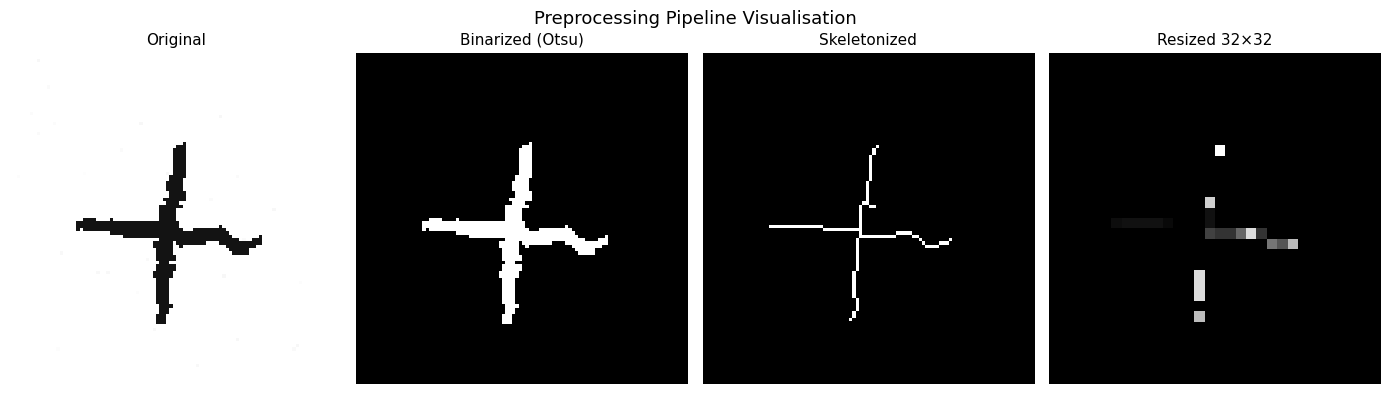

Stage 3 Complete ✅


In [12]:
# Visualise preprocessing stages for 1 sample image
sample_folder = list(class_mapping.keys())[0]
sample_path = os.path.join(dataset_path, sample_folder)
sample_file = os.path.join(sample_path,
                            os.listdir(sample_path)[0])

img_orig = cv2.imread(sample_file)
gray = cv2.cvtColor(img_orig, cv2.COLOR_BGR2GRAY)
_, binary = cv2.threshold(gray, 0, 255,
                           cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
skeleton = img_as_ubyte(skeletonize(binary > 0))
resized  = cv2.resize(skeleton, (32, 32))

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
titles = ['Original', 'Binarized (Otsu)', 'Skeletonized', 'Resized 32×32']
images = [cv2.cvtColor(img_orig, cv2.COLOR_BGR2RGB), binary, skeleton, resized]
cmaps  = [None, 'gray', 'gray', 'gray']

for ax, title, image, cmap in zip(axes, titles, images, cmaps):
    ax.imshow(image, cmap=cmap)
    ax.set_title(title, fontsize=11)
    ax.axis('off')

plt.suptitle('Preprocessing Pipeline Visualisation', fontsize=13)
plt.tight_layout()
plt.savefig('preprocessing_stages.png', dpi=150)
plt.show()
print("Stage 3 Complete ✅")

---
# STAGE 4 — Exploratory Data Analysis (EDA)
**Author: Adithyan**  
**Branch: feature/stage4-eda**

---

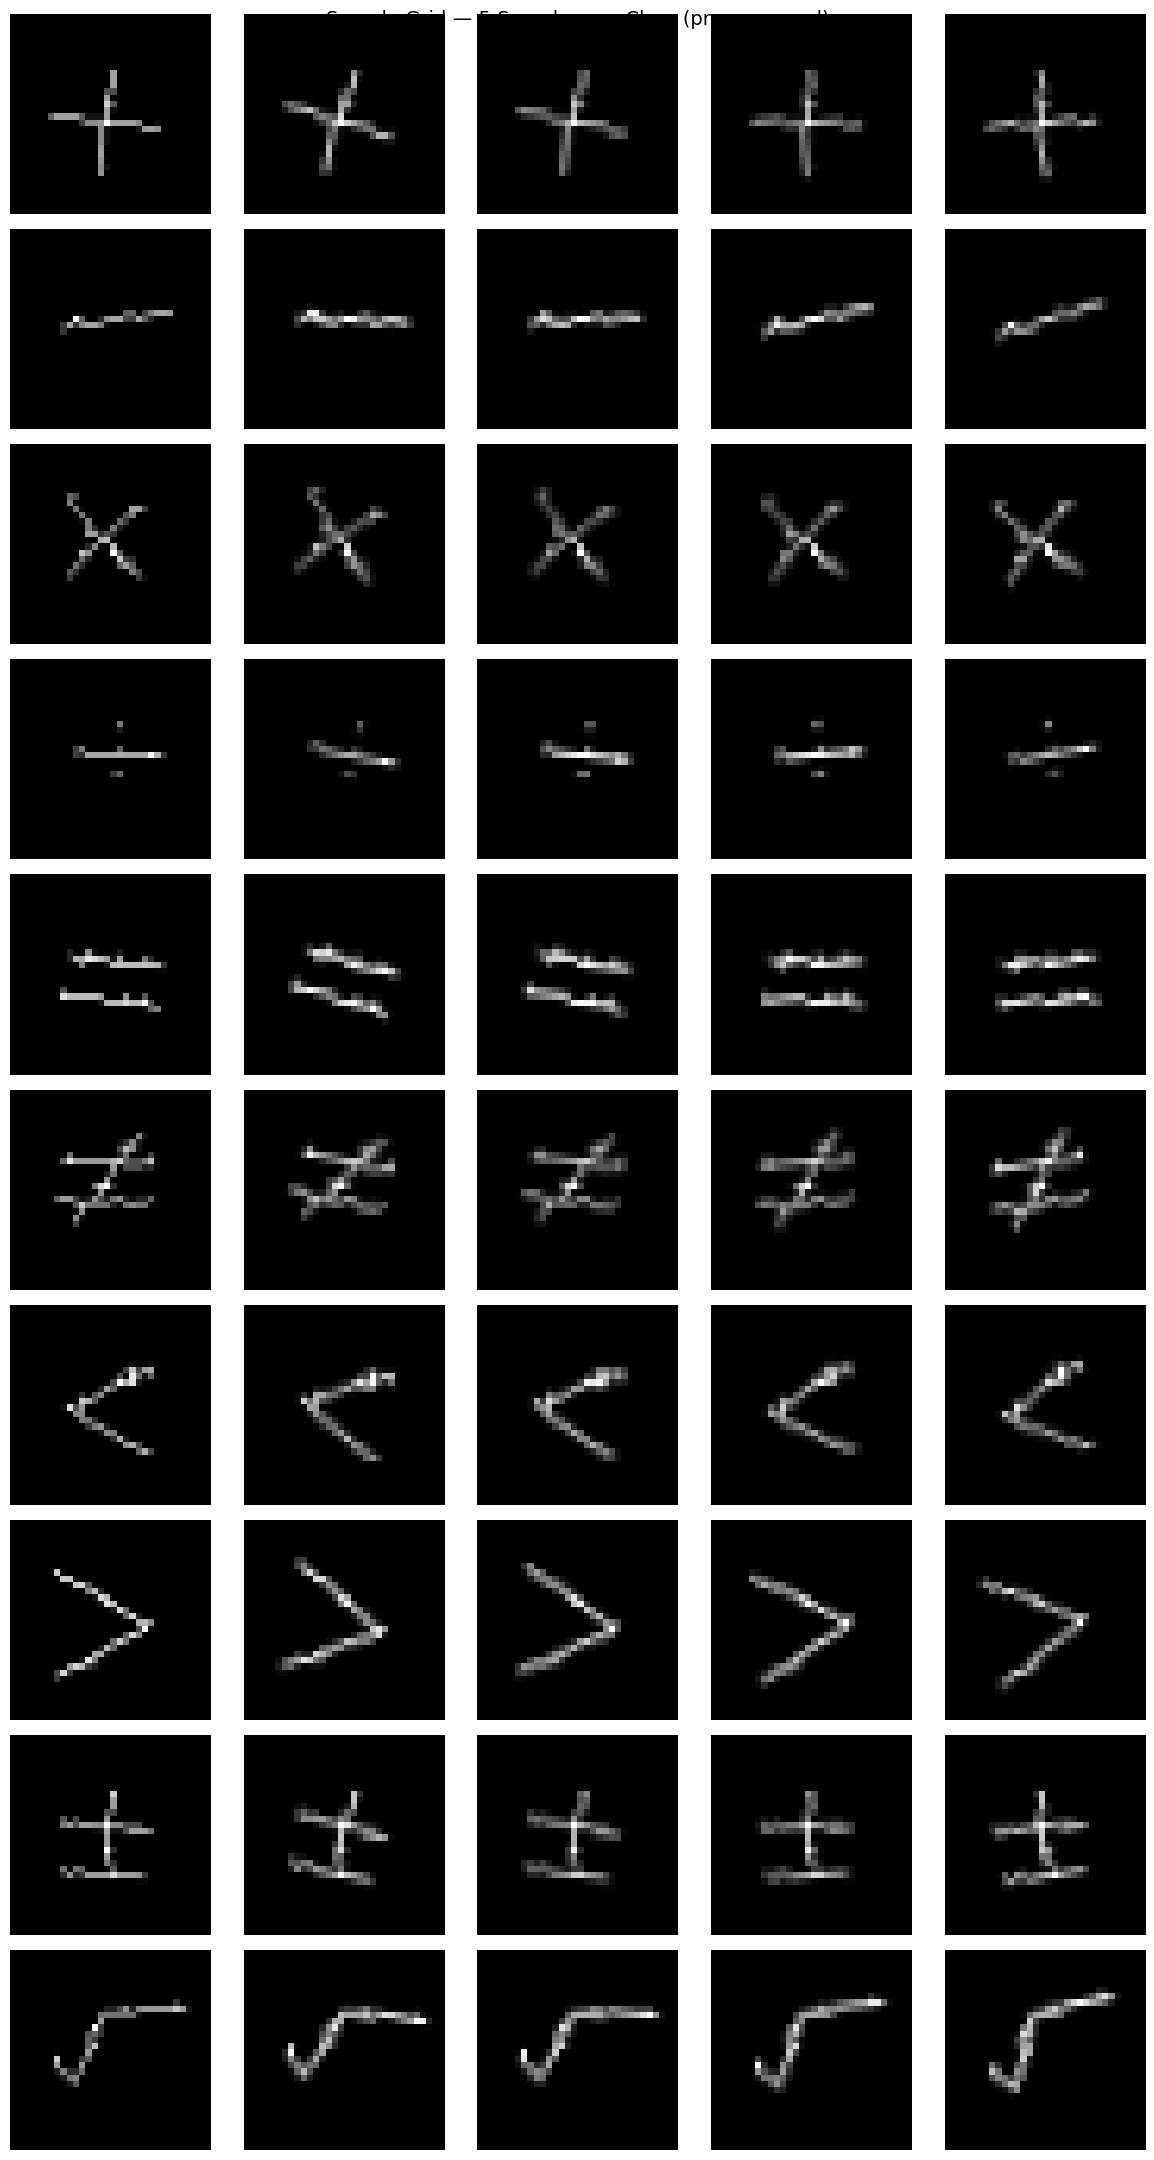

In [13]:
# ============================================================
# STAGE 4 — EXPLORATORY DATA ANALYSIS
# Author: Adithyan
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

symbols = list(class_mapping.values())
idx_to_symbol = {v: k for k, v in label_map.items()}

# ── 4.1 Sample Grid: 5 samples per class ──────────────────
fig, axes = plt.subplots(10, 5, figsize=(12, 22))
fig.suptitle('Sample Grid — 5 Samples per Class (preprocessed)', fontsize=14)

for class_idx, symbol in enumerate(symbols):
    class_samples = X[y == class_idx][:5]
    for col, sample in enumerate(class_samples):
        ax = axes[class_idx][col]
        ax.imshow(sample.reshape(32, 32), cmap='gray')
        if col == 0:
            ax.set_ylabel(symbol, fontsize=14, rotation=0, labelpad=20)
        ax.axis('off')

plt.tight_layout()
plt.savefig('eda_sample_grid.png', dpi=150)
plt.show()

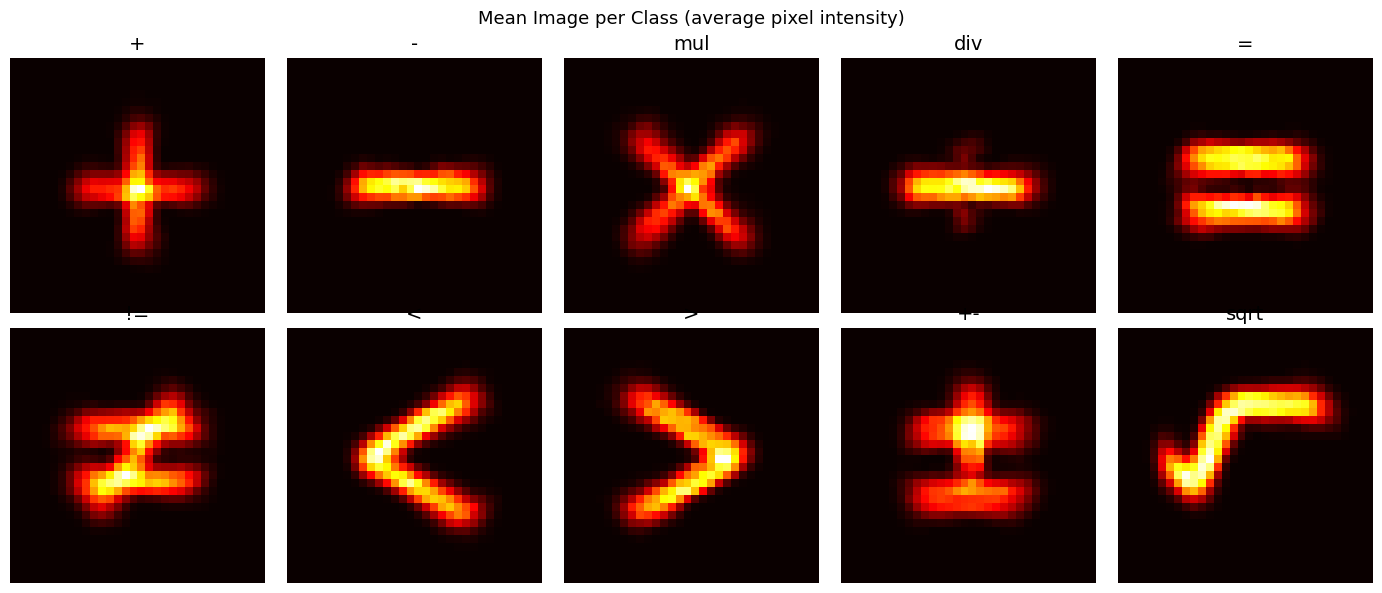

In [14]:
# ── 4.2 Mean Image per Class ──────────────────────────────
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.suptitle('Mean Image per Class (average pixel intensity)', fontsize=13)

for ax, (class_idx, symbol) in zip(axes.flatten(),
                                    enumerate(symbols)):
    class_samples = X[y == class_idx]
    mean_img = class_samples.mean(axis=0).reshape(32, 32)
    ax.imshow(mean_img, cmap='hot')
    ax.set_title(symbol, fontsize=14)
    ax.axis('off')

plt.tight_layout()
plt.savefig('eda_mean_images.png', dpi=150)
plt.show()

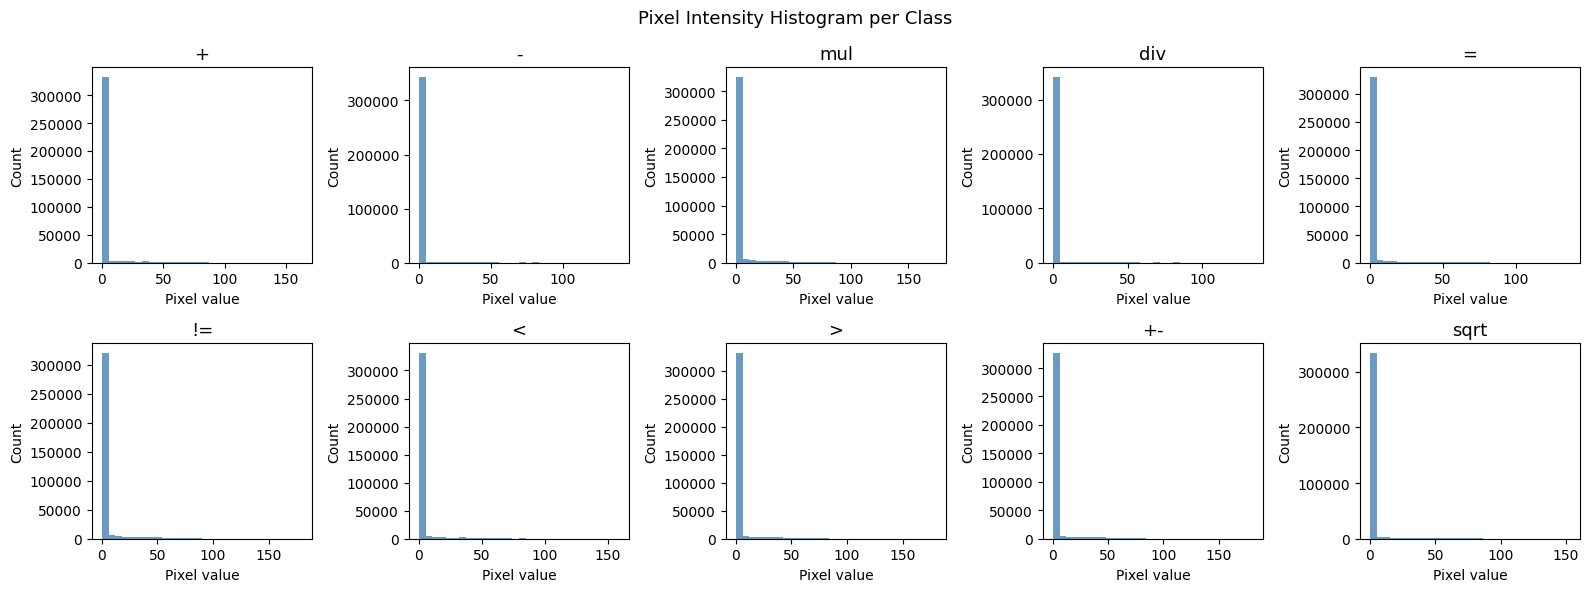

In [15]:
# ── 4.3 Pixel Intensity Distribution per Class ────────────
fig, axes = plt.subplots(2, 5, figsize=(16, 6))
fig.suptitle('Pixel Intensity Histogram per Class', fontsize=13)

for ax, (class_idx, symbol) in zip(axes.flatten(),
                                    enumerate(symbols)):
    class_samples = X[y == class_idx]
    ax.hist(class_samples.flatten(), bins=30,
            color='steelblue', edgecolor='none', alpha=0.8)
    ax.set_title(symbol, fontsize=13)
    ax.set_xlabel('Pixel value')
    ax.set_ylabel('Count')

plt.tight_layout()
plt.savefig('eda_histograms.png', dpi=150)
plt.show()

In [16]:
# ── 4.4 Identify Visually Confusable Pairs ────────────────
print("Visually confusable symbol pairs (based on structural similarity):")
confusable_pairs = [
    ('+', '÷', 'Both have a vertical stroke — differ only in horizontal bar position'),
    ('<', '>', 'Mirror images — easy to confuse if strokes are unclear'),
    ('=', '≠', 'Nearly identical — ≠ adds a diagonal slash through ='),
    ('+', '±', '± is an extension of + with a minus bar below'),
    ('−', '÷', 'Division sign contains a horizontal bar like minus'),
]

for s1, s2, reason in confusable_pairs:
    print(f"  {s1} vs {s2}: {reason}")

print("\n✅ Stage 4 EDA Complete")

Visually confusable symbol pairs (based on structural similarity):
  + vs ÷: Both have a vertical stroke — differ only in horizontal bar position
  < vs >: Mirror images — easy to confuse if strokes are unclear
  = vs ≠: Nearly identical — ≠ adds a diagonal slash through =
  + vs ±: ± is an extension of + with a minus bar below
  − vs ÷: Division sign contains a horizontal bar like minus

✅ Stage 4 EDA Complete
